# 시계열 패널 분석 — 근거문장의 시점으로 본 연도별 추이

본 분석(루트 README)과 별개의 탐색 분석이다. 해석 계층·점수 정의는 그대로 두고, 근거문장 10,020건에 사건 연도를 붙여 같은 EvidenceScore 산식을 연도별로 다시 센다. 각 셀은 `timeseries_panel_v7.py`의 함수를 부른다. 규칙·산식은 `시계열_패널분석_상세명세서.docx`, 결과 문서는 `시계열_패널분석_V7.md`.

In [1]:
import sys, json, csv
from pathlib import Path
HERE = Path.cwd() if (Path.cwd() / "timeseries_panel_v7.py").exists() else Path.cwd() / "시계열분석"
sys.path.insert(0, str(HERE))
import pandas as pd, numpy as np
import timeseries_panel_v7 as ts
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 30)
D = ts.D; OUT = ts.OUT
flat = ts.rows(D / "bullets_flat_v7_final.csv"); ev = ts.rows(ts.REPO / "v7_final_10020" / "index_methodology" / "evidence_score_by_sentence_v7.csv"); prov = ts.rows(D / "bullet_provenance_v7.csv")
print("문장", len(flat), "| 점수 CSV", len(ev), "| 시점 태그 CSV", len(prov))

문장 10020 | 점수 CSV 10020 | 시점 태그 CSV 10020


## A. 문장 시점 태깅

우선순위: 본문 연도(여럿이면 가장 늦은 연도) → URL 날짜 + 상대 표현(지난해·올해 …) → URL 날짜. 아무것도 없으면 `none`.

In [2]:
tags = ts.tag_sentences(flat)
for t, r in zip(tags, flat): t["_text"] = r["text"]
tg = pd.DataFrame([{k: v for k, v in t.items() if k != "_text"} for t in tags])
print(tg["year_source"].value_counts().to_dict())
print("시점 태그 비율:", round((tg["year_source"] != "none").mean(), 4))
both = tg[(tg["text_url_gap"] != "")].copy(); both["gap"] = both["text_url_gap"].astype(int)
print("본문 연도·URL 연도 둘 다:", len(both), "| 같은 해:", (both["gap"] == 0).sum(), "| ±1년:", (both["gap"].abs() <= 1).sum())
tg[tg["event_year"] != ""]["event_year"].astype(int).value_counts().sort_index().loc[2015:2026]

{'text': 5996, 'none': 3490, 'url': 522, 'relative': 12}
시점 태그 비율: 0.6517
본문 연도·URL 연도 둘 다: 741 | 같은 해: 664 | ±1년: 710


event_year
2015     124
2016     192
2017     159
2018     211
2019     231
2020     272
2021     215
2022     351
2023     487
2024     735
2025    1258
2026    1523
Name: count, dtype: int64

## B·E. 팬덤×연도 패널

칸 = (팬덤, 사건 연도). 규모 = EvidenceScore 합, 밀도 = 문장당 평균. 5문장 미만 칸은 결측(`valid_cell=0`), 축별 밀도는 3문장 이상일 때만. 연도 점유율과 후기 추가 비율(r41∼r72)도 함께 둔다.

In [3]:
panel, year_total, round_dist, untagged, cell = ts.build_panel(tags, ev, prov)
pn = pd.DataFrame(panel); print("칸", len(pn), "| 유효 칸", int(pn["valid_cell"].sum()), "| 유효 연도 3개 이상 팬덤", (pn[pn.valid_cell == 1].groupby("fandom").size() >= 3).sum())
pn[pn["fandom"] == "BTS"]

칸 847 | 유효 칸 414 | 유효 연도 3개 이상 팬덤 85


,fandom,year,n_loyalty,n_spillover,n_total,loyalty_sum,spillover_sum,loyalty_density,spillover_density,year_share,late_round_share,valid_cell
64,BTS,2017,3,2,5,5.8,3.3,1.9333,,0.03145,0.4000,1
65,BTS,2018,2,7,9,4.0,10.1,,1.4429,0.04265,0.1111,1
66,BTS,2019,4,6,10,7.8,13.8,1.95,2.3,0.04329,0.4000,1
67,BTS,2020,5,11,16,10.1,22.2,2.02,2.0182,0.05882,0.3125,1
68,BTS,2021,2,6,8,4.8,10.9,,1.8167,0.03721,0.3750,1
69,BTS,2022,2,6,8,4.5,10.1,,1.6833,0.02279,0.2500,1
70,BTS,2023,0,6,6,0.0,12.6,,2.1,0.01232,0.0000,1
71,BTS,2024,1,6,7,1.5,11.2,,1.8667,0.00952,0.2857,1
72,BTS,2025,4,8,12,8.5,14.7,2.125,1.8375,0.00954,0.3333,1
73,BTS,2026,15,39,54,26.4,68.8,1.76,1.7641,0.03546,0.2037,1


In [4]:
ys = pd.DataFrame(ts.year_stats(panel)); ys

,year,n_sentences,n_fandoms_any,n_fandoms_valid,r_density,p_density,rho_density,r_sum,mean_loyalty_density,mean_spillover_density
0,2015,124,44,3,,,,,,
1,2016,192,49,2,,,,,,
2,2017,159,52,2,,,,,,
3,2018,211,56,7,,,,,,
4,2019,231,56,9,,,,,,
5,2020,272,69,7,,,,,,
6,2021,215,69,4,,,,,,
7,2022,351,77,11,,,,,,
8,2023,487,82,23,0.3107,0.149,0.3179,0.2515,1.7718,1.6652
9,2024,735,97,28,0.0181,0.9273,0.0834,0.6245,1.8284,1.8219


### 검증 — 연도별 합 + 연도 미상 = 현재 raw 점수

In [5]:
scores = {r["fandom"]: r for r in ts.load(D / "fandom_scores_live_reference_v7.json")}; ok = 0
for f, s in scores.items():
    ls = sum(c["loyalty_sum"] for (ff, y), c in cell.items() if ff == f); ss = sum(c["spillover_sum"] for (ff, y), c in cell.items() if ff == f)
    un = [e for t, e in zip(tags, ev) if t["fandom"] == f and (not t["event_year"] or int(t["event_year"]) not in ts.YEARS)]
    ls += sum(float(e["evidence_score"]) for e in un if e["bullet_type"] == "loyalty"); ss += sum(float(e["evidence_score"]) for e in un if e["bullet_type"] == "spillover")
    ok += abs(ls - s["loyalty_raw"]) < 1e-6 and abs(ss - s["spillover_raw"]) < 1e-6
print("raw 점수 재현:", f"{ok}/100")

raw 점수 재현: 100/100


## 통계 — 팬덤별 추세, 고정효과 회귀, 부트스트랩

In [6]:
tr = pd.DataFrame(ts.fandom_trends(panel)); tr[tr["rho_loyalty_density"] != ""].head(15)

,fandom,n_valid_years,first_year,last_year,peak_year_volume,rho_volume,rho_loyalty_density,p_loyalty_density,rho_spillover_density,p_spillover_density
0,BTS,10,2017,2026,2026,0.3283,0.0,1.0,-0.0333,0.9322
1,TWICE,10,2016,2026,2025,0.7841,0.4,0.6,-0.2,0.5796
2,레드벨벳,8,2017,2026,2025,0.6347,-0.7,0.1881,-0.3964,0.3786
3,오마이걸,8,2017,2026,2026,0.5183,-0.8,0.2,0.7827,0.0657
4,GOT7,7,2015,2025,2025,0.3784,-0.4,0.6,-0.4857,0.3287
5,NCT,7,2020,2026,2026,0.8469,-0.1429,0.7872,-0.3143,0.5441
9,EXO,6,2018,2026,2026,0.0883,-0.8,0.2,-0.2,0.704
10,SEVENTEEN,6,2019,2026,2024,0.8117,-0.6,0.2848,0.1,0.8729
13,김호중,6,2020,2026,2024,-0.3479,-0.6,0.2848,-0.7,0.1881
14,영탁,6,2020,2026,2024,0.7247,0.1,0.8729,0.4286,0.3965


In [7]:
reg = ts.panel_regressions(panel)
for k in ("loyalty_density", "spillover_density"): print(k, {kk: v for kk, v in reg[k].items() if kk != "year_effects_vs_2015"})
print("loyalty–spillover panel:", reg["loyalty_spillover_panel"])

loyalty_density {'n_cells': 272, 'n_fandoms': 98, 'r2_fandom_fe': 0.537, 'r2_two_way_fe': 0.5899, 'year_fe_F': 1.914, 'year_fe_p': 0.040884743139956076, 'late_round_share_coef': 0.1556, 'late_round_share_p': 0.38601553513066617}
spillover_density {'n_cells': 373, 'n_fandoms': 99, 'r2_fandom_fe': 0.4202, 'r2_two_way_fe': 0.4598, 'year_fe_F': 1.748, 'year_fe_p': 0.06334663397825141, 'late_round_share_coef': -0.029, 'late_round_share_p': 0.8013901286030839}
loyalty–spillover panel: {'pooled_coef': 0.2754, 'pooled_p': 1.3841931714404416e-06, 'within_coef_two_way_fe': 0.067, 'within_p': 0.439905214140706, 'n_cells': 231}


In [8]:
ranked = sorted(scores, key=lambda f: -(scores[f]["loyalty_score"] + scores[f]["spillover_score"])); pv = pn[pn.valid_cell == 1].groupby("fandom").size()
top8 = [f for f in ranked if pv.get(f, 0) >= 3][:8]; boots = ts.bootstrap_cells(cell, top8); pd.DataFrame(boots).head(12)

,fandom,year,loyalty_density,loyalty_lo,loyalty_hi,spillover_density,spillover_lo,spillover_hi
0,BTS,2017,1.9333,1.0,2.8,,,
1,BTS,2018,,,,1.4429,1.0714,2.0429
2,BTS,2019,1.95,1.25,2.8531,2.3,1.8167,2.8167
3,BTS,2020,2.02,1.36,2.84,2.0182,1.645,2.4639
4,BTS,2021,,,,1.8167,1.6833,1.9333
5,BTS,2022,,,,1.6833,1.2167,2.0837
6,BTS,2023,,,,2.1,1.7667,2.3833
7,BTS,2024,,,,1.8667,1.4829,2.2167
8,BTS,2025,2.125,1.325,2.8512,1.8375,1.45,2.2625
9,BTS,2026,1.76,1.3198,2.28,1.7641,1.5076,2.0256


## C. 경로(F1∼F5) 비중의 연도 추이 — 근사

저장된 재현 K=8 모델(옛 토크나이저)의 문서-토픽 분포 θ를 토픽 대응표(Hungarian)로 공식 토픽에 잇고 공식 토픽→F 배정으로 접는다. 대응 Jaccard가 낮은 토픽이 있어 방향 참고용이다.

In [9]:
per_fy, per_f, n_docs, topic_map = ts.factor_shares_by_year(tags, None); print("θ 문서 수", n_docs); pd.DataFrame(topic_map).T

θ 문서 수 9954


,official_topic,F,jaccard_top10
0,7,F1,0.1111
1,3,F2,0.6667
2,5,F3,0.25
3,2,F3,0.25
4,6,F3,0.1765
5,4,F3,0.1765
6,1,F5,0.5385
7,0,F4,0.5385


In [10]:
fs = pd.read_csv(OUT / "fandom_year_factor_share_v7.csv"); tr2 = pd.read_csv(OUT / "persona_transition_v7.csv")
print("첫·마지막 유효 연도 페르소나가 다른 팬덤:", int(tr2["changed"].sum()), "/", len(tr2)); tr2.head(10)

첫·마지막 유효 연도 페르소나가 다른 팬덤: 63 / 100


,fandom,n_years,first_year,first_persona,last_year,last_persona,changed,n_switches,path,official_persona_all_years
0,레드벨벳,8,2017,현장상업형,2026,글로벌투어형,1,4,2017:현장상업형 → 2018:현장상업형 → 2021:현장상업형 → 2022:글로...,원정소비형
1,GOT7,7,2015,글로벌결속형,2025,현장상업형,1,6,2015:글로벌결속형 → 2018:집단동원형 → 2019:글로벌투어형 → 2020:...,글로벌투어형
2,NCT,7,2020,글로벌결속형,2026,현장상업형,1,4,2020:글로벌결속형 → 2021:산업확장형 → 2022:현장상업형 → 2023:현...,글로벌투어형
3,Zion.T,7,2015,글로벌투어형,2025,원정소비형,1,6,2015:글로벌투어형 → 2016:브랜드동반형 → 2017:원정소비형 → 2019:...,글로벌투어형
4,BTOB,6,2015,집단동원형,2026,원정소비형,1,4,2015:집단동원형 → 2016:글로벌투어형 → 2020:원정소비형 → 2022:글...,글로벌투어형
5,EXO,6,2018,브랜드동반형,2026,현장상업형,1,3,2018:브랜드동반형 → 2020:집단동원형 → 2023:원정소비형 → 2024:현...,글로벌투어형
6,SEVENTEEN,6,2019,현장상업형,2026,글로벌투어형,1,4,2019:현장상업형 → 2022:집단동원형 → 2023:집단동원형 → 2024:현장...,글로벌투어형
7,김호중,6,2020,글로벌투어형,2026,현장상업형,1,5,2020:글로벌투어형 → 2022:현장상업형 → 2023:원정소비형 → 2024:현...,집단동원형
8,영탁,6,2020,현장상업형,2026,글로벌투어형,1,3,2020:현장상업형 → 2022:원정소비형 → 2023:현장상업형 → 2024:현장...,원정소비형
9,청하,6,2019,현장상업형,2026,글로벌투어형,1,1,2019:현장상업형 → 2020:현장상업형 → 2023:현장상업형 → 2024:현장...,글로벌투어형


## 그림

`timeseries_panel_v7.py`가 만든 PNG 4장(`output/`).

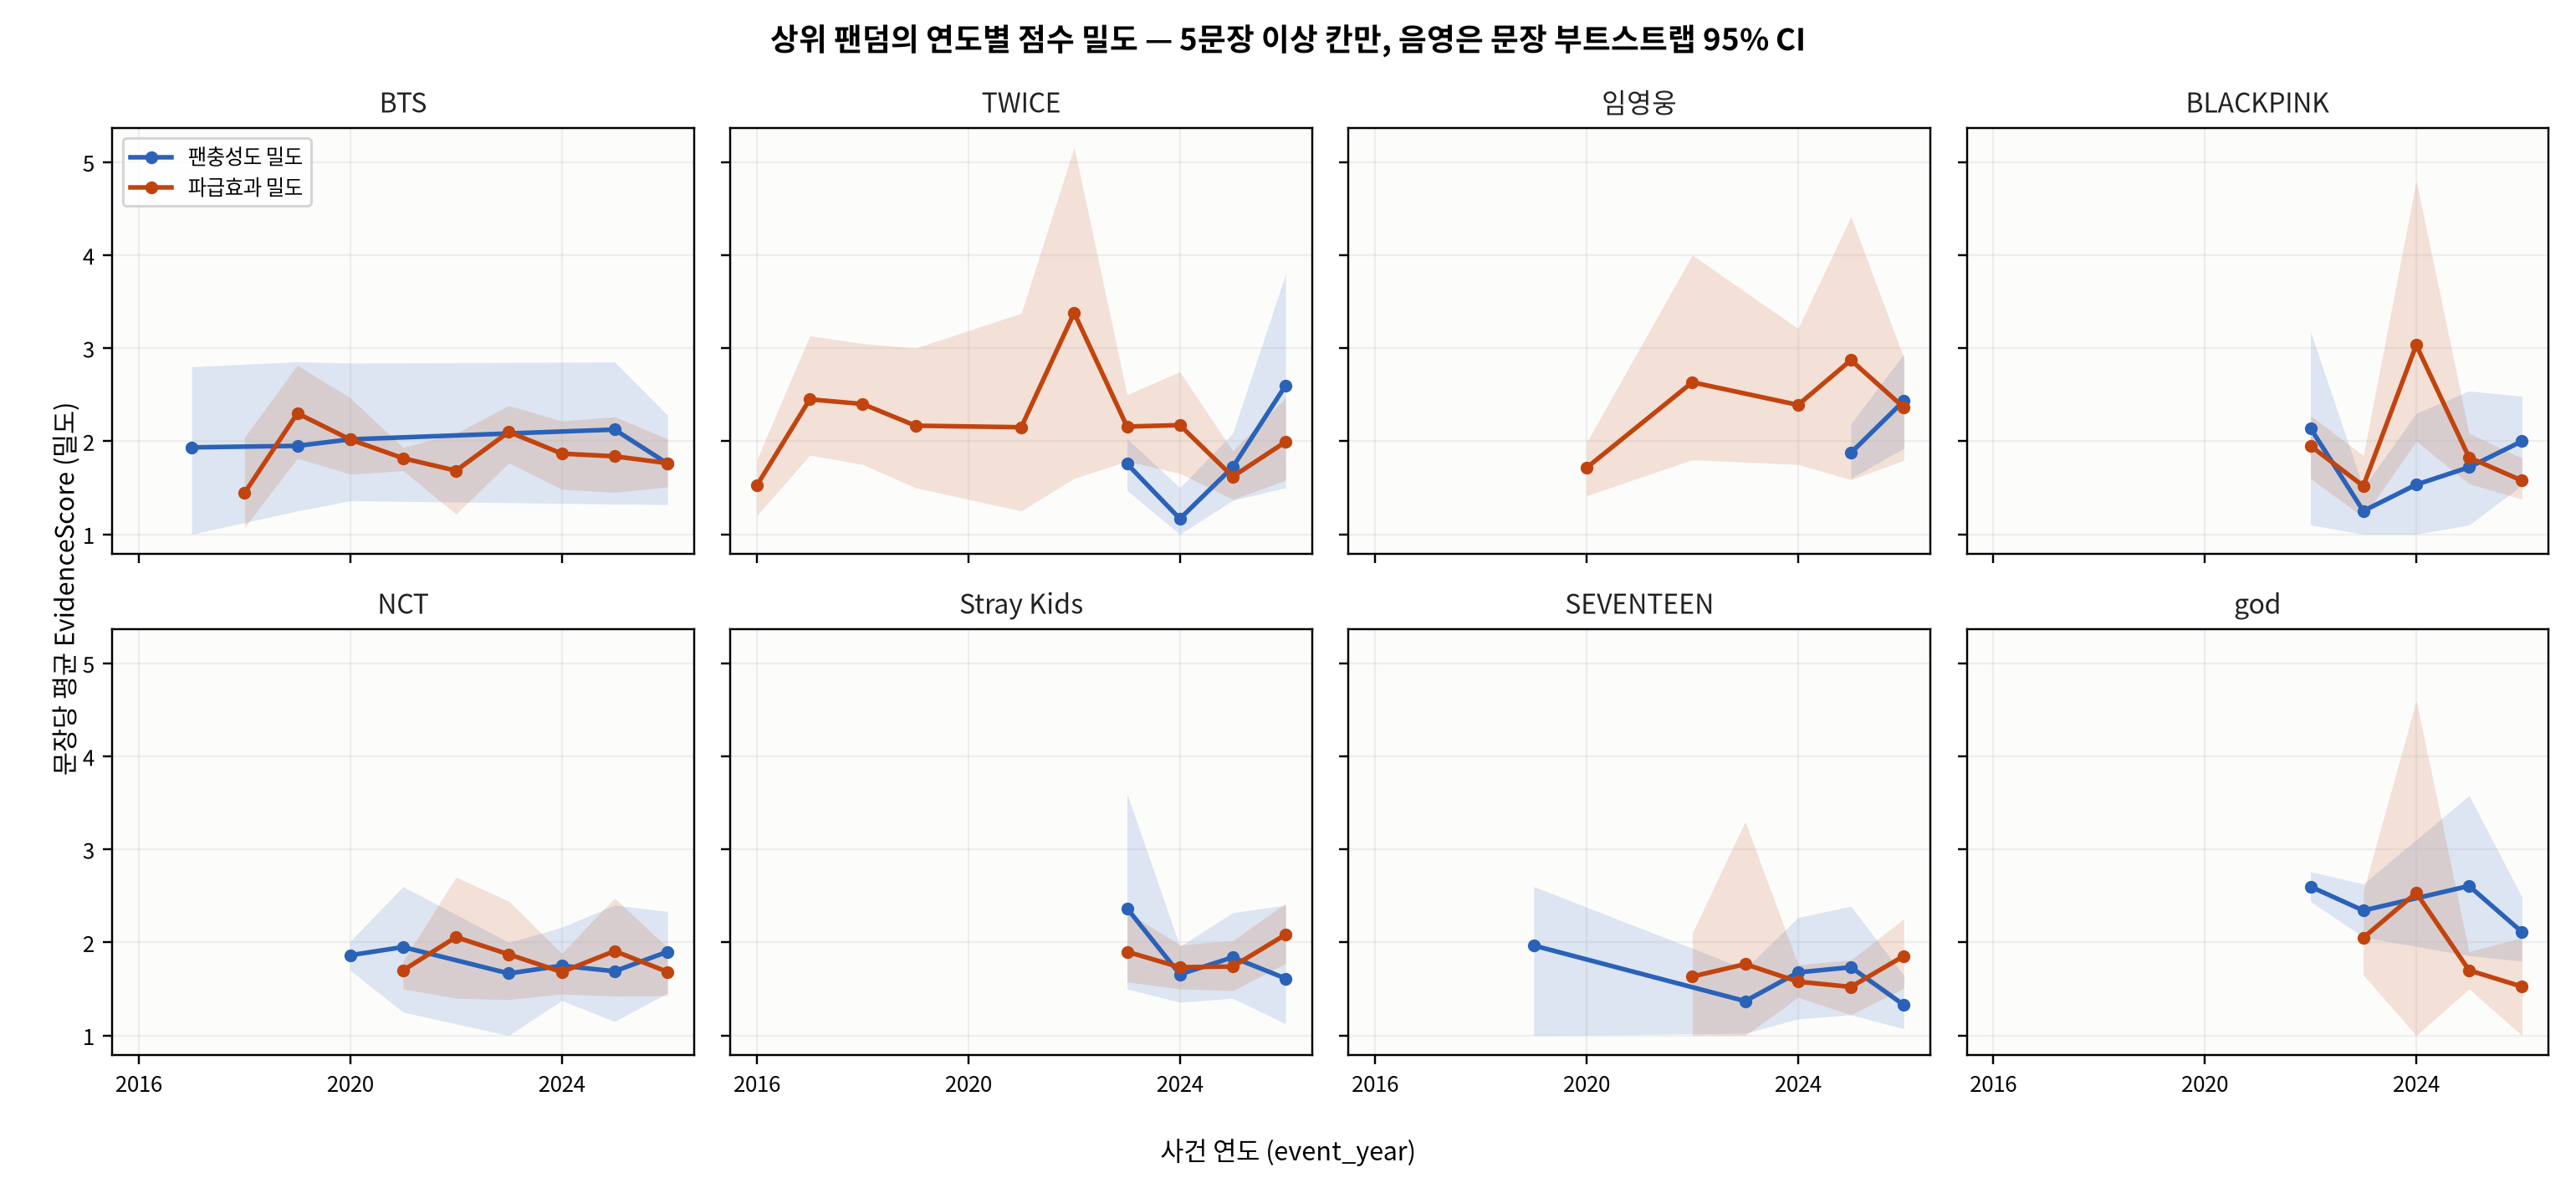

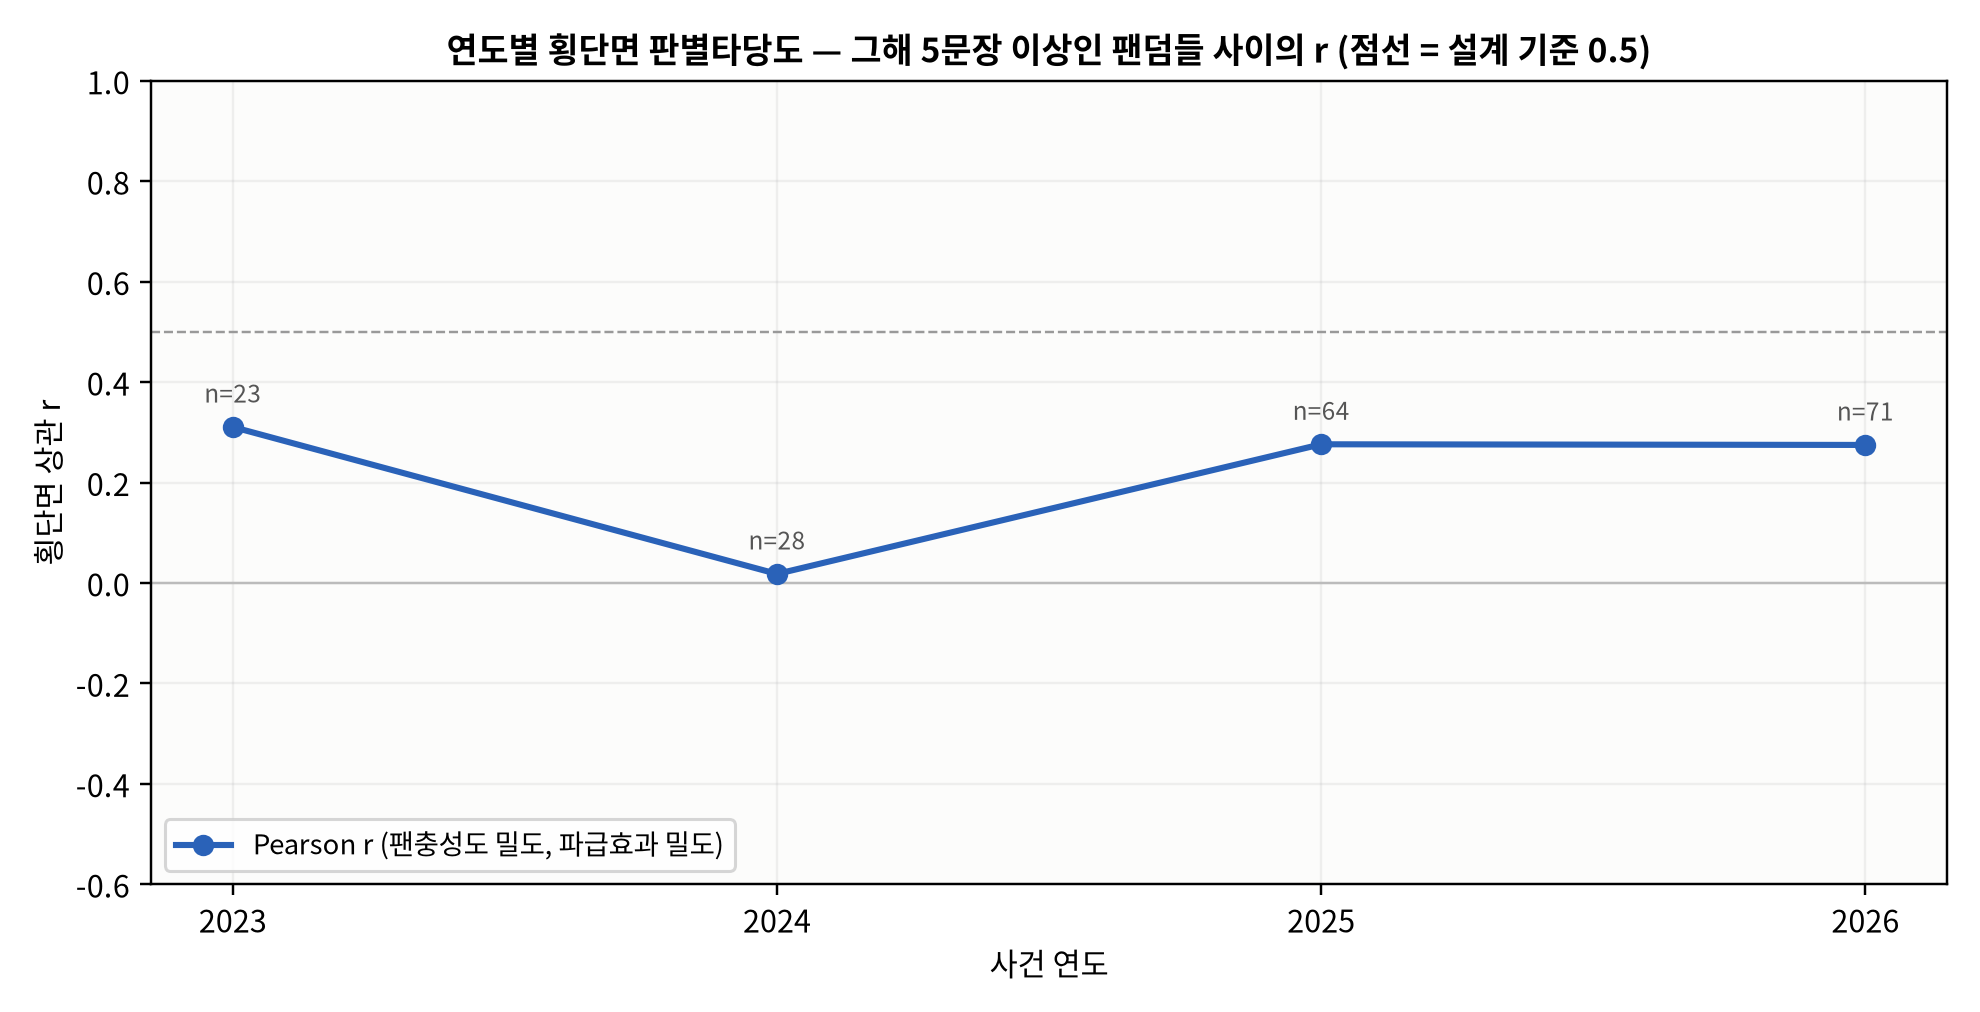

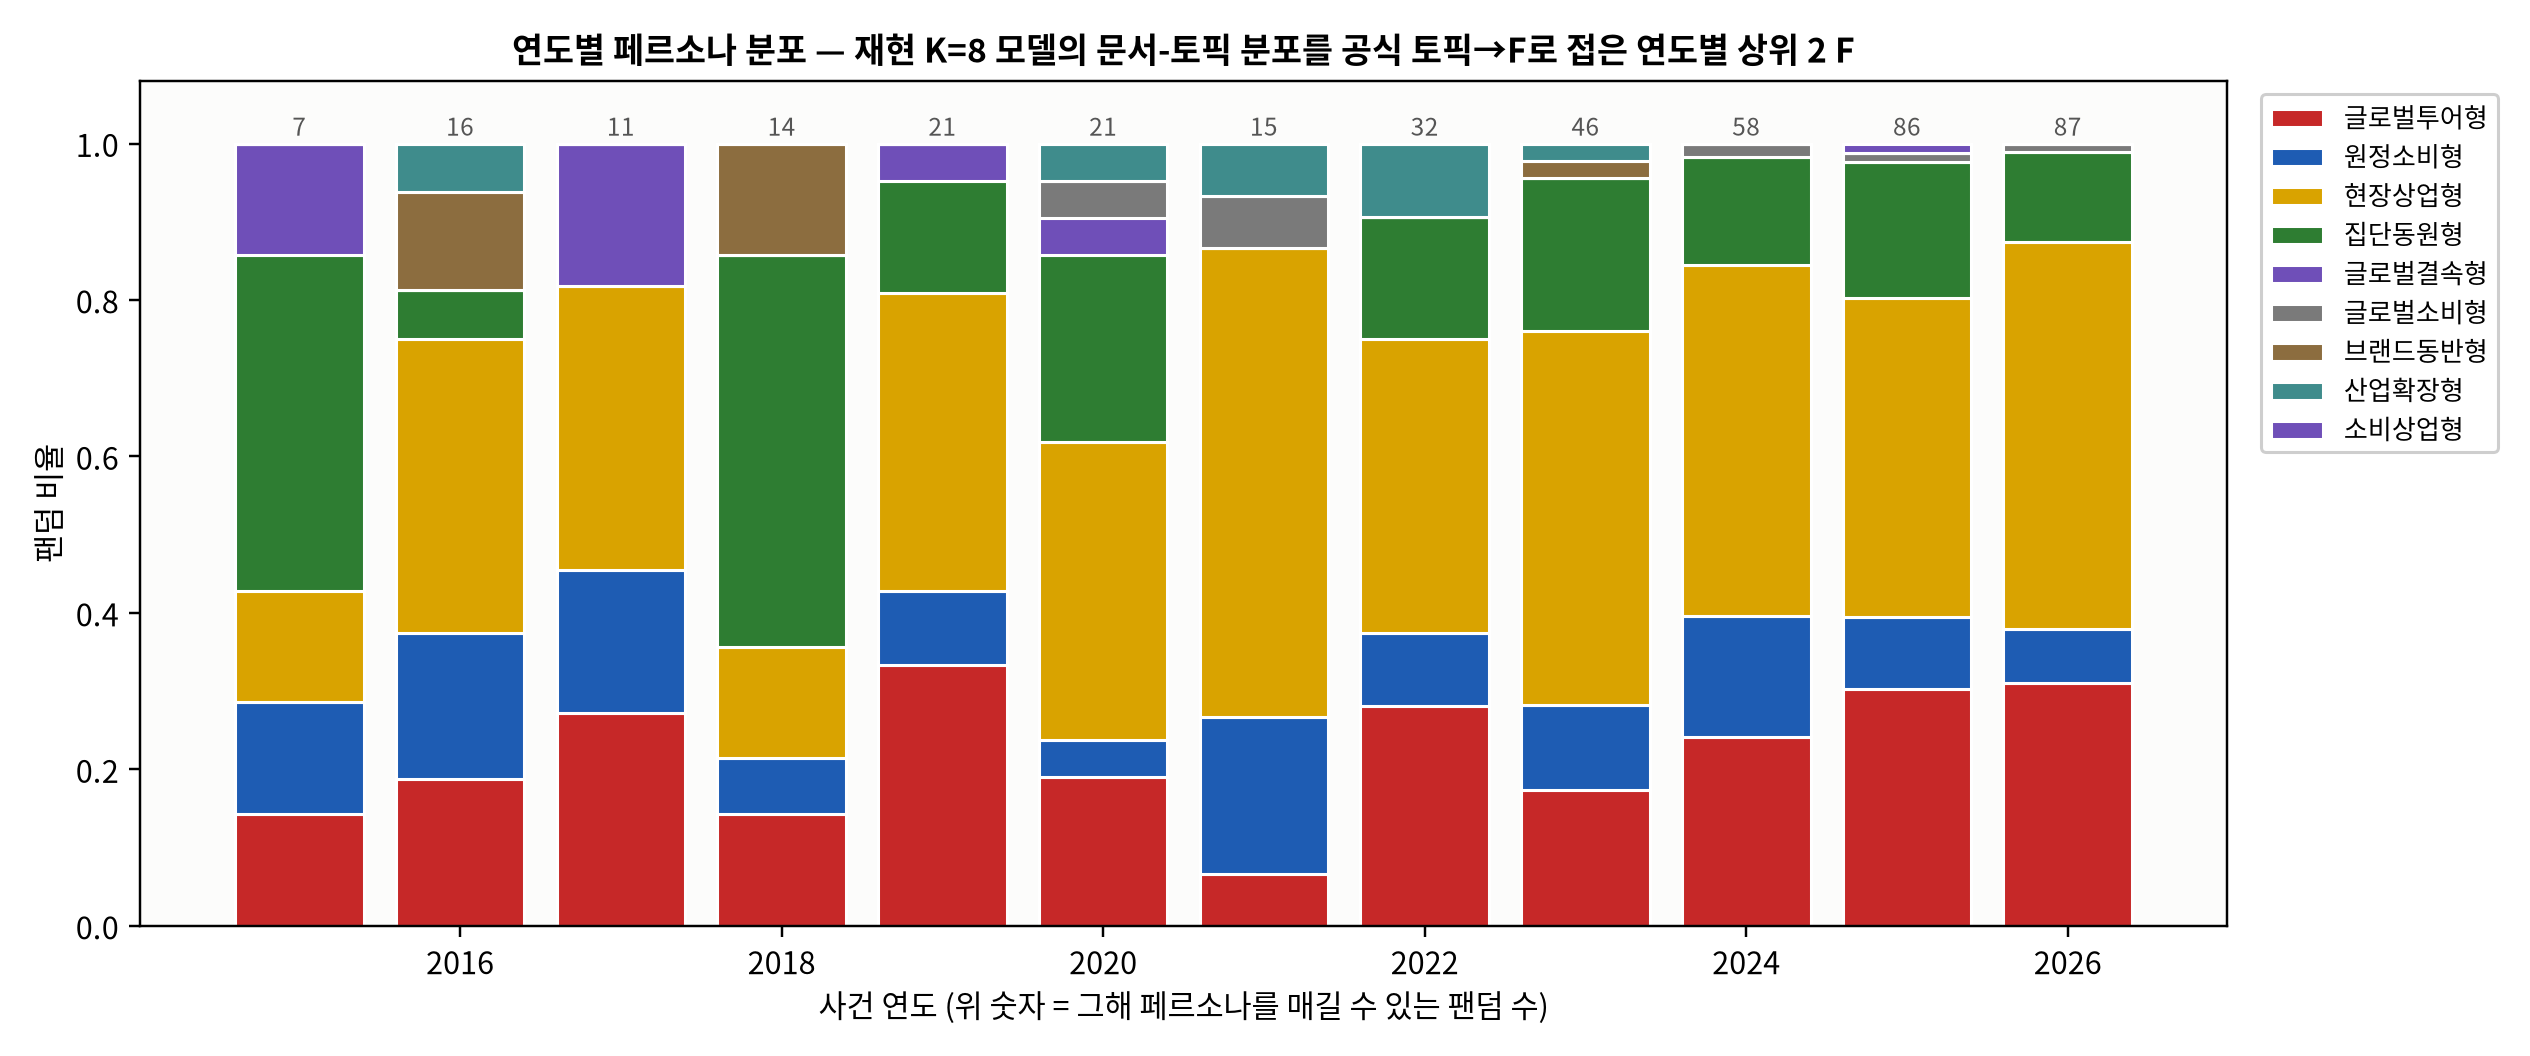

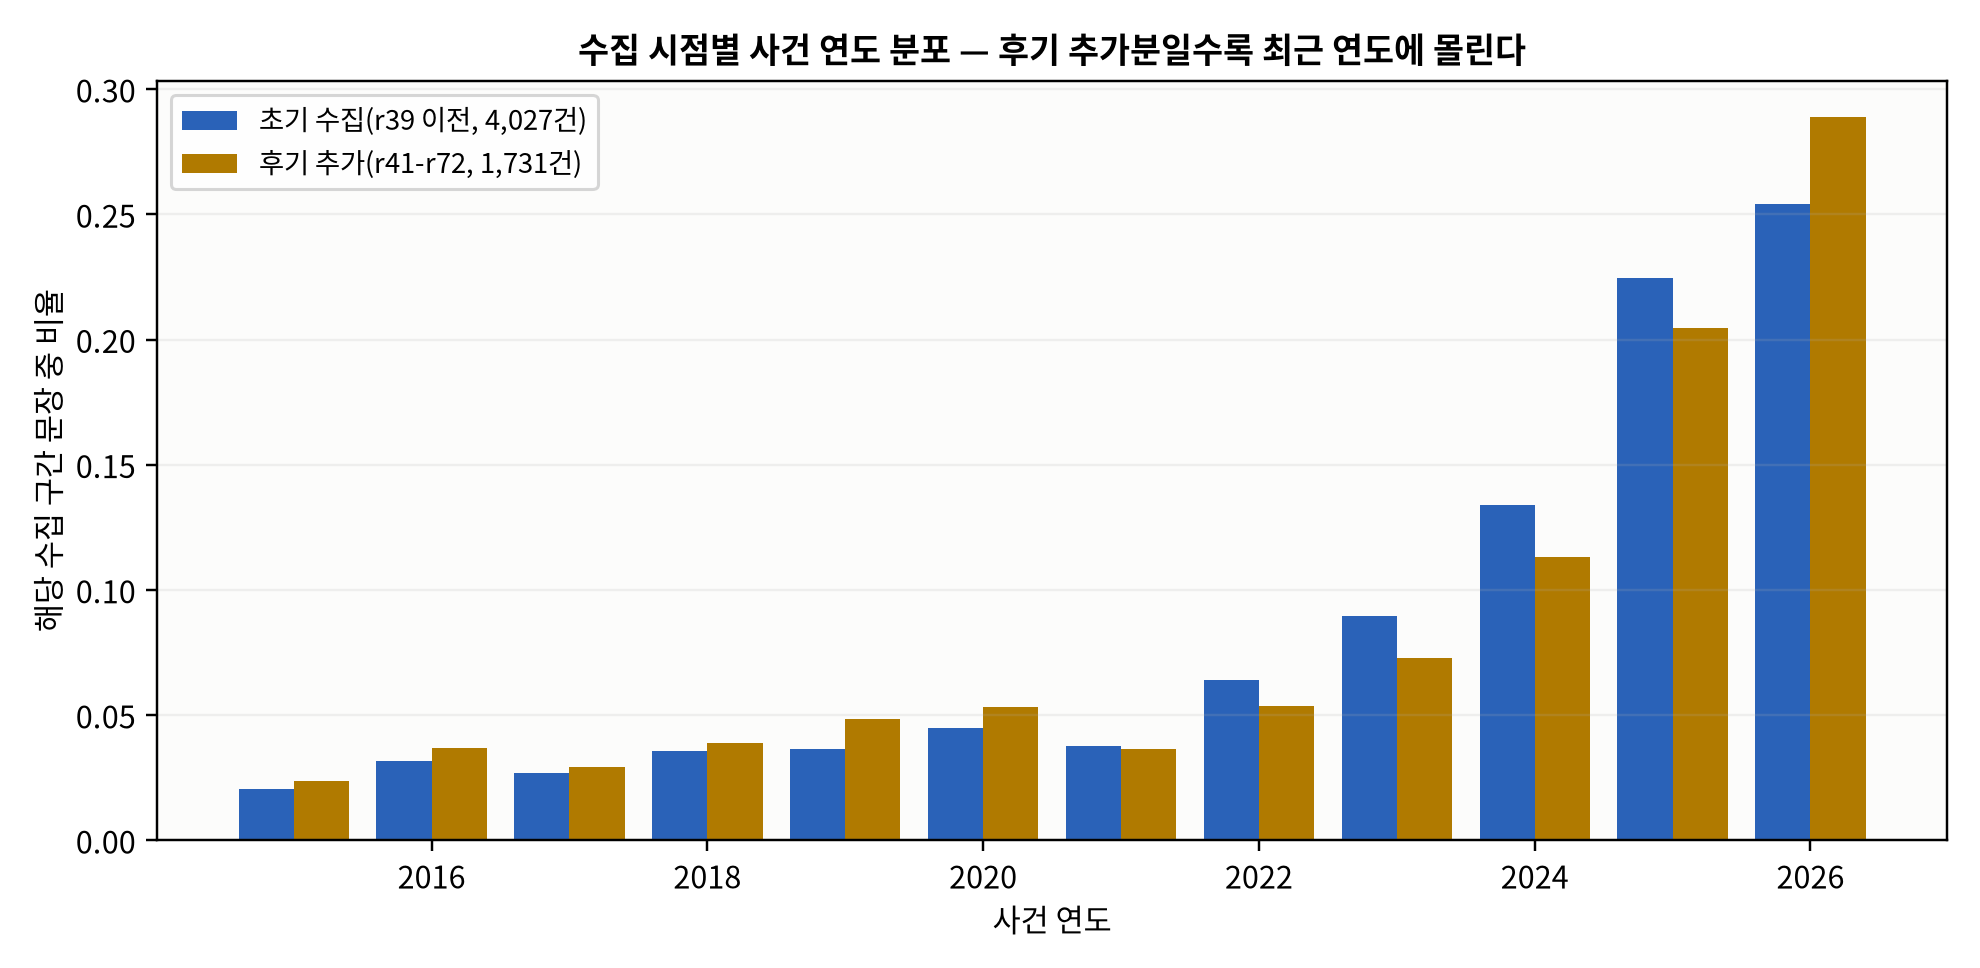

In [11]:
from IPython.display import Image, display
for f in ["fig_ts01_year_profiles.png", "fig_ts02_yearwise_corr.png", "fig_ts03_persona_by_year.png", "fig_ts04_round_year_bias.png"]: display(Image(filename=str(OUT / f), width=900))

## 요약 JSON

`output/summary_v7.json`의 핵심 값. 상세명세서·R 코드는 이 파일을 대조한다.

In [12]:
S = json.load(open(OUT / "summary_v7.json", encoding="utf-8"))
print(json.dumps({k: S[k] for k in ("A_time_tags", "B_panel")}, ensure_ascii=False, indent=1)[:1500])

{
 "A_time_tags": {
  "n": 10020,
  "by_source": {
   "text": 5996,
   "none": 3490,
   "url": 522,
   "relative": 12
  },
  "tagged": 6530,
  "tagged_share": 0.6517,
  "in_range_2015_2026": 5758,
  "event_year_dist": {
   "2015": 124,
   "2016": 192,
   "2017": 159,
   "2018": 211,
   "2019": 231,
   "2020": 272,
   "2021": 215,
   "2022": 351,
   "2023": 487,
   "2024": 735,
   "2025": 1258,
   "2026": 1523
  },
  "before_2015": 772,
  "text_url_both": 741,
  "text_url_same_year": 664,
  "text_url_within_1y": 710,
  "multi_year_sentences": 1005
 },
 "B_panel": {
  "n_cells": 847,
  "n_valid_cells": 414,
  "fandoms_ge3_valid_years": 85,
  "fandoms_ge5_valid_years": 39,
  "fandoms_excluded_lt3": [
   "CORTIS",
   "아이오아이",
   "잭스키스",
   "Hearts2Hearts",
   "A-pink",
   "브라운아이즈",
   "sg워너비",
   "보아",
   "이승철",
   "FTISLAND",
   "케이윌",
   "김연자",
   "이문세",
   "백지영",
   "박정현"
  ],
  "raw_score_reconciliation": "100/100",
  "top8": [
   "BTS",
   "TWICE",
   "임영웅",
   "BLACKPINK",
   "NCT",
